In [19]:
import duckdb
import pandas as pd

In [12]:
con = duckdb.connect("../../duckdb/NKX2-2_TL4B2_no_err_corr_rim.db")
tables = con.execute("SHOW TABLES").fetchdf()
tables

,name
0,trebl_experiment_a1_ADBC_Rim_Puro_R1_T0ND_S179...
1,trebl_experiment_a1_ADBC_Rim_Puro_R1_T0ND_S179...
2,trebl_experiment_a1_ADBC_Rim_Puro_R1_T0ND_S179...
3,trebl_experiment_a1_ADBC_Rim_Puro_R1_T0ND_S179...
4,trebl_experiment_a1_ADBC_Rim_Puro_R1_T0ND_S179...
...,...
235,trebl_experiment_r4_RTBC_Rim_Puro_R4_T0ND_S206...
236,trebl_experiment_r4_RTBC_Rim_Puro_R4_T0ND_S206...
237,trebl_experiment_r4_RTBC_Rim_Puro_R4_T0ND_S206...
238,trebl_experiment_r4_RTBC_Rim_Puro_R4_T0ND_S206...


In [13]:
tables["name"].iloc[1]

'trebl_experiment_a1_ADBC_Rim_Puro_R1_T0ND_S179_ADBC2_HawkBCs_loss_summary'

In [14]:
for name in tables[tables["name"].str.contains("R2_T24")]["name"]:
    print(name)

trebl_experiment_a34_ADBC_Rim_Puro_R2_T24_S188_ADBC2_HawkBCs_initial
trebl_experiment_a34_ADBC_Rim_Puro_R2_T24_S188_ADBC2_HawkBCs_loss_summary
trebl_experiment_a34_ADBC_Rim_Puro_R2_T24_S188_ADBC2_HawkBCs_quality
trebl_experiment_a34_ADBC_Rim_Puro_R2_T24_S188_ADBC2_HawkBCs_quality_umis_collapsed
trebl_experiment_a34_ADBC_Rim_Puro_R2_T24_S188_ADBC2_HawkBCs_unique_barcodes
trebl_experiment_r34_RTBC_Rim_Puro_R2_T24_S196_RTBC_initial
trebl_experiment_r34_RTBC_Rim_Puro_R2_T24_S196_RTBC_loss_summary
trebl_experiment_r34_RTBC_Rim_Puro_R2_T24_S196_RTBC_quality
trebl_experiment_r34_RTBC_Rim_Puro_R2_T24_S196_RTBC_quality_umis_collapsed
trebl_experiment_r34_RTBC_Rim_Puro_R2_T24_S196_RTBC_unique_barcodes


In [17]:
con.execute("SELECT * FROM trebl_experiment_a34_ADBC_Rim_Puro_R2_T24_S188_ADBC2_HawkBCs_quality LIMIT 5").fetchdf()

,ADBC2,ADBC2_qual,HawkBCs,HawkBCs_qual,UMI,UMI_qual,Designed
0,CGTTAC,True,CAGGTTCTC,True,CGGGACGGTANT,True,1
1,AGCCCA,True,CCATCGGTT,True,AGAATCAAACNA,True,1
2,GTCAAC,True,ACAGTCCTT,True,ACTGCAAATGNC,True,1
3,TACGGC,True,AAGGATCTG,True,ATTAAAGACAAA,True,1
4,TTAGGC,True,CAACAGTGC,True,CAGTGTAATGNC,True,1


In [38]:
con.execute("""
COPY (
    SELECT '_' || UMI AS umi_col,
           ADBC2 || HawkBCs AS barcode_col
    FROM trebl_experiment_a34_ADBC_Rim_Puro_R2_T24_S188_ADBC2_HawkBCs_quality
    ORDER BY ADBC2 || HawkBCs
) TO '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/data/rim_no_err_corr_T0ND_umi_count_test.tsv'
WITH (FORMAT 'csv', DELIMITER E'\t', HEADER FALSE)
""")

In [39]:
pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/data/rim_no_err_corr_T0ND_umi_count_test.tsv", nrows = 100, sep = "\t")

,_GGAAGCGGAAGG,AAAAAAAAGCCAACT
0,_TTGATCGATGTG,AAAAAAACAAGAAGC
1,_CGACAGCCAATG,AAAAAAACAAGAAGC
2,_TGCTTACTGCTG,AAAAAAACAAGAAGC
3,_ATGGTTCGGTTA,AAAAAAACAAGCGTT
4,_ATCCCTTTAACT,AAAAAAACGAGCGTT
...,...,...
95,_TCACTCATAAGA,AAAAAAATTCTCGCC
96,_CACAAAGCCTAA,AAAAAAATTCTCGCC
97,_ACTCAGCTTAAG,AAAAAAATTCTCGCC
98,_GAGAAGTAGGTG,AAAAAAATTCTCGCC


In [40]:
# umi_tools count_tab \
#     -S /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/data/rim_no_err_corr_T0ND_umi_count_test_output.tsv \
#     < /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/data/rim_no_err_corr_T0ND_umi_count_test.tsv

In [53]:
new_output = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/data/rim_no_err_corr_T0ND_umi_count_test_output.tsv", sep = "\t")
new_output

,gene,count
0,AAAAAAAAGCCAACT,1
1,AAAAAAACAAGAAGC,3
2,AAAAAAACAAGCGTT,1
3,AAAAAAACGAGCGTT,1
4,AAAAAAAGAGAGAAC,1
...,...,...
19543,TTTTTTATAAGAGTT,1
19544,TTTTTTATAGGAGTT,1
19545,TTTTTTCATGAGTGA,1
19546,TTTTTTCGAGGAGTT,1


In [54]:
old_output = pd.read_csv("../../output/NKX2-2/TL4B2/rim/no_err_corr/trebl_experiment_a34_ADBC_Rim_Puro_R2_T24_S188/a34_ADBC_Rim_Puro_R2_T24_S188_directional_umi_counts.tsv", sep = "\t")
old_output

,gene,count
0,CAACGGCAAGGAACA,9915
1,ATTCTTCATACGATC,12027
2,TGTGTGAACAGAGTC,3399
3,CCATAACACCGATTG,25457
4,ATGTAAAACCATCCA,2498
...,...,...
19503,ACTAGACATACGATC,1
19504,AAAATAATGAACTCC,1
19505,TATAGAACAACCTGC,1
19506,CCCTGCCCCTATCCG,1


In [55]:
merged_counts = pd.merge(new_output, old_output, suffixes = ("_new", "_old"), on = 'gene', how = 'outer')
merged_counts

,gene,count_new,count_old
0,AAAAAAAAGCCAACT,1,1.0
1,AAAAAAACAAGAAGC,3,3.0
2,AAAAAAACAAGCGTT,1,1.0
3,AAAAAAACGAGCGTT,1,1.0
4,AAAAAAAGAGAGAAC,1,1.0
...,...,...,...
19543,TTTTTTATAAGAGTT,1,1.0
19544,TTTTTTATAGGAGTT,1,1.0
19545,TTTTTTCATGAGTGA,1,1.0
19546,TTTTTTCGAGGAGTT,1,1.0


In [56]:
merged_counts[merged_counts["count_old"].isna()]

,gene,count_new,count_old
419,AAAGTNCATGTTGCC,1,NaN
462,AAAGTTCATGNTGCC,2,NaN
878,AACCGCATCCNCTGT,1,NaN
921,AACCTAATGANCTCC,2,NaN
1345,AAGCTCACAANCCAC,1,NaN
1616,AATAATCCATNGGTT,1,NaN
1873,AATGTACACGNGATC,1,NaN
1929,AATTCAAGCANTGTA,1,NaN
1970,AATTGAATGANCTCC,1,NaN
2025,AATTTCCCATNAACG,1,NaN


In [46]:
import seaborn as sns

<Axes: xlabel='count_old', ylabel='count_new'>

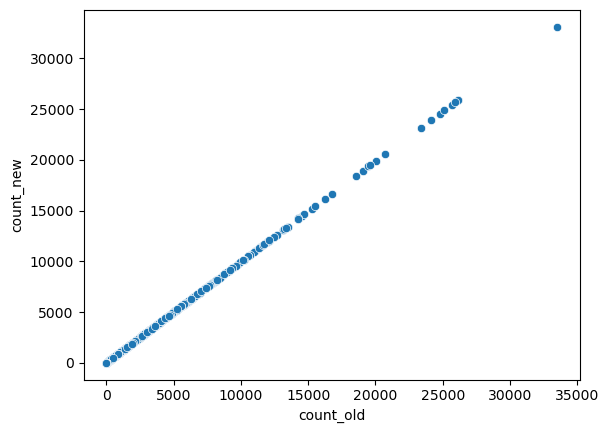

In [47]:
sns.scatterplot(data = merged_counts, x = "count_old", y = "count_new")

In [ ]:
# Both have the same output yay!! Can avoid the bowtie steps!!